# Dự báo Doanh thu Bán hàng
## 6. Huấn luyện mô hình Gradient Boosting (LightGBM)

Chúng ta thực hiện tối ưu hóa siêu tham số và huấn luyện mô hình hồi quy **Gradient Boosting** trên tập dữ liệu dự báo doanh thu bán hàng:
1. Mô hình tự viết từ đầu: `LightGBMFromScratch` (Tích hợp chia bin Histogram-based và phát triển cây Leaf-wise)
2. Mô hình chuẩn từ thư viện: `LGBMRegressor` của LightGBM

Chúng ta sử dụng cross-validation với lưới tham số tối ưu để tìm ra bộ siêu tham số tốt nhất, so sánh các chỉ số sai số (MAE, RMSE, R²) và trực quan hóa kết quả.

### Cơ chế hoạt động của thuật toán Gradient Boosting & LightGBM

#### 1. Nguyên lý Gradient Boosting tổng quát
Gradient Boosting xây dựng mô hình cộng dồn bằng cách huấn luyện tuần tự các mô hình yếu (Weak Learners, thường là Decision Tree Regressors) để giảm thiểu hàm mất mát $L(y, \hat{y})$:
$$\hat{y}^{(0)}(x) = \arg\min_c \sum_{i=1}^N L(y_i, c)$$
Tại mỗi bước $m = 1, 2, \dots, M$, mô hình học cách khớp với **phần dư (Residuals)** hoặc âm đạo hàm của hàm mất mát (Negative Gradients):
$$r_{im} = -\left[ \frac{\partial L(y_i, f(x_i))}{\partial f(x_i)} \right]_{f(x) = \hat{y}^{(m-1)}(x)}$$
Cây quyết định hồi quy mới $h_m(x)$ được khớp trên tập dữ liệu mới $\{(x_i, r_{im})\}_{i=1}^N$. Sau đó, mô hình được cập nhật theo tỷ lệ học tập (Learning Rate) $\eta$:
$$\hat{y}^{(m)}(x) = \hat{y}^{(m-1)}(x) + \eta \cdot h_m(x)$$

#### 2. Các tối ưu hóa cốt lõi của LightGBM
*   **Histogram-based Decision Tree Algorithm:** Chia các giá trị đặc trưng liên tục vào $K$ bins (thùng) rời rạc để giảm độ phức tạp tìm điểm cắt từ $O(\text{data} \times \text{feature})$ xuống $O(\text{bin} \times \text{feature})$.
*   **Leaf-wise (Best-first) Tree Growth:** Thay vì phát triển cây theo từng mức (Level-wise) như XGBoost, LightGBM chọn node có độ giảm loss lớn nhất để chia nhánh (Leaf-wise), giúp đạt độ sâu tối ưu nhanh hơn và giảm thiểu sai số tốt hơn khi kết hợp với `max_depth`.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import time
import os
import sys
import warnings
warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')

# Thêm thư mục root vào sys.path để import utils
sys.path.append(os.path.abspath(os.path.join('..')))
from practice_2.utils.custom_cv import CustomKFold
from practice_2.utils.custom_hyperparameter_tuning import CustomGridSearchCV

# Đường dẫn nạp dữ liệu
DATA_DIR = './data/ready_for_train'

X_train = joblib.load(os.path.join(DATA_DIR, 'X_train_final.pkl'))
X_test = joblib.load(os.path.join(DATA_DIR, 'X_test_final.pkl'))
y_train = joblib.load(os.path.join(DATA_DIR, 'y_train_log.pkl'))
y_test = joblib.load(os.path.join(DATA_DIR, 'y_test_log.pkl'))

# Chuyển nhãn về dạng 1D numpy array
if hasattr(y_train, 'values'):
    y_train = y_train.values.flatten()
else:
    y_train = np.array(y_train).flatten()

if hasattr(y_test, 'values'):
    y_test = y_test.values.flatten()
else:
    y_test = np.array(y_test).flatten()

print('Kích thước tập Train:', X_train.shape)
print('Kích thước tập Test :', X_test.shape)

Kích thước tập Train: (79448, 31)
Kích thước tập Test : (19862, 31)


### 6.1 Mô hình LightGBM tự viết từ đầu (Scratch)

In [2]:
import sys
import numpy as np

class LeafNode:
    def __init__(self, sample_indices, depth, weight, score):
        self.sample_indices = sample_indices
        self.depth = depth
        self.weight = weight
        self.score = score
        self.is_leaf = True
        
        self.feature_idx = None
        self.threshold = None
        self.left_child = None
        self.right_child = None
        self.gain = -1.0

class LeafWiseTreeRegressor:
    def __init__(self, max_depth=3, max_leaf_nodes=8, l2_reg=1.0, min_child_samples=5):
        self.max_depth = max_depth
        self.max_leaf_nodes = max_leaf_nodes
        self.l2_reg = l2_reg
        self.min_child_samples = min_child_samples
        self.root = None
        self.leaves = []

    def _find_best_split(self, X_binned, gradients, sample_indices, n_bins):
        n_samples = len(sample_indices)
        if n_samples <= 2 * self.min_child_samples:
            return None, None, -1.0
            
        G_total = np.sum(gradients[sample_indices])
        H_total = n_samples
        
        best_gain = -1.0
        best_feat = None
        best_thresh = None
        
        X_sub = X_binned[sample_indices]
        grad_sub = gradients[sample_indices]
        
        n_features = X_binned.shape[1]
        for f in range(n_features):
            max_val = int(np.max(X_sub[:, f]))
            if max_val == 0:
                continue
            
            hist_H = np.bincount(X_sub[:, f])
            hist_G = np.bincount(X_sub[:, f], weights=grad_sub)
            
            if len(hist_G) < max_val + 1:
                hist_G = np.pad(hist_G, (0, max_val + 1 - len(hist_G)))
                hist_H = np.pad(hist_H, (0, max_val + 1 - len(hist_H)))
                
            G_L = 0.0
            H_L = 0
            
            for b in range(len(hist_G) - 1):
                G_L += hist_G[b]
                H_L += hist_H[b]
                G_R = G_total - G_L
                H_R = H_total - H_L
                
                if H_L >= self.min_child_samples and H_R >= self.min_child_samples:
                    gain = 0.5 * (
                        (G_L ** 2) / (H_L + self.l2_reg) +
                        (G_R ** 2) / (H_R + self.l2_reg) -
                        (G_total ** 2) / (H_total + self.l2_reg)
                    )
                    if gain > best_gain:
                        best_gain = gain
                        best_feat = f
                        best_thresh = b
                        
        return best_feat, best_thresh, best_gain

    def fit(self, X_binned, gradients, n_bins):
        n_samples = X_binned.shape[0]
        G_total = np.sum(gradients)
        H_total = n_samples
        
        root_weight = G_total / (H_total + self.l2_reg)
        root_score = 0.5 * (G_total ** 2) / (H_total + self.l2_reg)
        
        self.root = LeafNode(np.arange(n_samples), depth=0, weight=root_weight, score=root_score)
        active_leaves = [self.root]
        
        feat, thresh, gain = self._find_best_split(X_binned, gradients, self.root.sample_indices, n_bins)
        self.root.feature_idx = feat
        self.root.threshold = thresh
        self.root.gain = gain
        
        leaf_count = 1
        
        while leaf_count < self.max_leaf_nodes:
            best_leaf_idx = -1
            best_gain = -1.0
            for i, leaf in enumerate(active_leaves):
                if leaf.gain > best_gain and leaf.depth < self.max_depth:
                    best_gain = leaf.gain
                    best_leaf_idx = i
            
            if best_leaf_idx == -1 or best_gain <= 0.0:
                break
                
            leaf_to_split = active_leaves.pop(best_leaf_idx)
            
            feature_idx = leaf_to_split.feature_idx
            threshold = leaf_to_split.threshold
            
            left_mask = X_binned[leaf_to_split.sample_indices, feature_idx] <= threshold
            left_indices = leaf_to_split.sample_indices[left_mask]
            right_indices = leaf_to_split.sample_indices[~left_mask]
            
            G_L = np.sum(gradients[left_indices])
            H_L = len(left_indices)
            left_weight = G_L / (H_L + self.l2_reg)
            left_score = 0.5 * (G_L ** 2) / (H_L + self.l2_reg)
            
            G_R = np.sum(gradients[right_indices])
            H_R = len(right_indices)
            right_weight = G_R / (H_R + self.l2_reg)
            right_score = 0.5 * (G_R ** 2) / (H_R + self.l2_reg)
            
            left_child = LeafNode(left_indices, depth=leaf_to_split.depth + 1, weight=left_weight, score=left_score)
            right_child = LeafNode(right_indices, depth=leaf_to_split.depth + 1, weight=right_weight, score=right_score)
            
            leaf_to_split.left_child = left_child
            leaf_to_split.right_child = right_child
            leaf_to_split.is_leaf = False
            
            f_L, t_L, g_L = self._find_best_split(X_binned, gradients, left_child.sample_indices, n_bins)
            left_child.feature_idx = f_L
            left_child.threshold = t_L
            left_child.gain = g_L
            
            f_R, t_R, g_R = self._find_best_split(X_binned, gradients, right_child.sample_indices, n_bins)
            right_child.feature_idx = f_R
            right_child.threshold = t_R
            right_child.gain = g_R
            
            active_leaves.append(left_child)
            active_leaves.append(right_child)
            
            leaf_count += 1
            
        self.leaves = self._collect_leaves(self.root)

    def _collect_leaves(self, node):
        if node.is_leaf:
            return [node]
        return self._collect_leaves(node.left_child) + self._collect_leaves(node.right_child)

    def predict(self, X_binned):
        preds = np.zeros(X_binned.shape[0])
        self._predict_recursive(self.root, X_binned, np.arange(X_binned.shape[0]), preds)
        return preds
        
    def _predict_recursive(self, node, X_binned, indices, preds):
        if len(indices) == 0:
            return
        if node.is_leaf:
            preds[indices] = node.weight
            return
        left_mask = X_binned[indices, node.feature_idx] <= node.threshold
        self._predict_recursive(node.left_child, X_binned, indices[left_mask], preds)
        self._predict_recursive(node.right_child, X_binned, indices[~left_mask], preds)



In [2]:
class LightGBMFromScratch:
    def __init__(self, n_estimators=50, learning_rate=0.1, max_depth=5, max_leaf_nodes=15, n_bins=32, l2_reg=1.0, min_child_samples=5):
        self.n_estimators = n_estimators
        self.learning_rate = learning_rate
        self.max_depth = max_depth
        self.max_leaf_nodes = max_leaf_nodes
        self.n_bins = n_bins
        self.l2_reg = l2_reg
        self.min_child_samples = min_child_samples
        self.base_pred = None
        self.trees = []
        self.bin_edges = {}

    def get_params(self, deep=True):
        return {
            "n_estimators": self.n_estimators,
            "learning_rate": self.learning_rate,
            "max_depth": self.max_depth,
            "max_leaf_nodes": self.max_leaf_nodes,
            "n_bins": self.n_bins,
            "l2_reg": self.l2_reg,
            "min_child_samples": self.min_child_samples
        }

    def set_params(self, **parameters):
        for parameter, value in parameters.items():
            setattr(self, parameter, value)
        return self

    def _bin_features(self, X, fit=False):
        X_arr = np.array(X)
        X_binned = np.zeros(X_arr.shape, dtype=np.int32)
        for col in range(X_arr.shape[1]):
            if fit:
                unique_vals = np.unique(X_arr[:, col])
                if len(unique_vals) <= self.n_bins:
                    self.bin_edges[col] = ('unique', unique_vals)
                else:
                    percentiles = np.linspace(0, 100, self.n_bins + 1)
                    edges = np.percentile(X_arr[:, col], percentiles)
                    edges = np.unique(edges)
                    self.bin_edges[col] = ('edges', edges)
            
            bin_type, edges = self.bin_edges[col]
            if bin_type == 'unique':
                X_binned[:, col] = np.searchsorted(edges, X_arr[:, col])
            else:
                X_binned[:, col] = np.digitize(X_arr[:, col], edges[1:-1])
        return X_binned

    def fit(self, X, y):
        if hasattr(y, 'values'):
            y_arr = y.values.flatten()
        else:
            y_arr = np.array(y).flatten()
            
        X_binned = self._bin_features(X, fit=True)
        self.base_pred = np.mean(y_arr)
        f_m = np.full(len(y_arr), self.base_pred, dtype=np.float64)
        
        self.trees = []
        for i in range(self.n_estimators):
            gradient = y_arr - f_m
            tree = LeafWiseTreeRegressor(
                max_depth=self.max_depth,
                max_leaf_nodes=self.max_leaf_nodes,
                l2_reg=self.l2_reg,
                min_child_samples=self.min_child_samples
            )
            tree.fit(X_binned, gradient, self.n_bins)
            f_m += self.learning_rate * tree.predict(X_binned)
            self.trees.append(tree)
        return self

    def predict(self, X):
        X_binned = self._bin_features(X, fit=False)
        preds = np.full(X.shape[0], self.base_pred, dtype=np.float64)
        for tree in self.trees:
            preds += self.learning_rate * tree.predict(X_binned)
        return preds

sys.modules['__main__'].LightGBMFromScratch = LightGBMFromScratch


### 6.2 Huấn luyện và Tìm kiếm siêu tham số bằng Cross-Validation

In [3]:
from lightgbm import LGBMRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Định nghĩa các hàm tính toán thủ công độ đo trên thang đo thực tế (sau expm1)
def calculate_r2(y_true, y_pred):
    ss_res = np.sum((y_true - y_pred) ** 2)
    ss_tot = np.sum((y_true - np.mean(y_true)) ** 2)
    return 1.0 - (ss_res / ss_tot) if ss_tot > 0 else 0.0

# Lưu trữ kết quả đánh giá mô hình
results = {}

# Cấu hình tham số lưới và CV
param_grid = {
    'n_estimators': [30, 50],
    'learning_rate': [0.05, 0.1],
    'max_depth': [3, 5]
}
cv = CustomKFold(n_splits=3, shuffle=True, random_state=42)

# --- From Scratch với GridSearchCV ---
print('--- Tối ưu hóa siêu tham số cho LightGBM From Scratch ---')
lgb_scratch_base = LightGBMFromScratch(max_leaf_nodes=15, n_bins=32)
grid_scratch = CustomGridSearchCV(
    estimator=lgb_scratch_base,
    param_grid=param_grid,
    cv=cv,
    scoring='neg_mse' # sử dụng MSE để tối ưu hồi quy
)

t0 = time.time()
grid_scratch.fit(X_train, y_train)
t_fit_s = time.time() - t0

lgb_scratch = grid_scratch.best_estimator_

t0 = time.time()
y_pred_log_scratch = lgb_scratch.predict(X_test)
t_pred_s = time.time() - t0

# Mũ hóa ngược về giá trị thực tế
y_test_original = np.expm1(y_test)
y_pred_scratch = np.expm1(y_pred_log_scratch)

results['From Scratch'] = {
    'MAE_log':    mean_absolute_error(y_test, y_pred_log_scratch),
    'RMSE_log':   np.sqrt(mean_squared_error(y_test, y_pred_log_scratch)),
    'R2_log':     r2_score(y_test, y_pred_log_scratch),
    'MAE_orig':   mean_absolute_error(y_test_original, y_pred_scratch),
    'RMSE_orig':  np.sqrt(mean_squared_error(y_test_original, y_pred_scratch)),
    'R2_orig':    calculate_r2(y_test_original, y_pred_scratch),
    'fit_time':   t_fit_s,
    'pred_time':  t_pred_s
}
print(f"-> Tham số TỐT NHẤT: {grid_scratch.best_params_}")
print(f"-> Điểm MSE TỐT NHẤT (Log): {-grid_scratch.best_score_:.4f}")

# --- LightGBM Regressor của thư viện ---
print('\n--- Tối ưu hóa siêu tham số cho LightGBM Regressor (Library) ---')
lgb_sklearn_base = LGBMRegressor(num_leaves=15, max_bin=32, min_child_samples=1, random_state=42, verbose=-1, n_jobs=-1)
grid_sklearn = CustomGridSearchCV(
    estimator=lgb_sklearn_base,
    param_grid=param_grid,
    cv=cv,
    scoring='neg_mse'
)

t0 = time.time()
grid_sklearn.fit(X_train, y_train)
t_fit_sk = time.time() - t0

lgb_sklearn = grid_sklearn.best_estimator_

t0 = time.time()
y_pred_log_sklearn = lgb_sklearn.predict(X_test)
t_pred_sk = time.time() - t0

y_pred_sklearn = np.expm1(y_pred_log_sklearn)

results['LightGBM (Library)'] = {
    'MAE_log':    mean_absolute_error(y_test, y_pred_log_sklearn),
    'RMSE_log':   np.sqrt(mean_squared_error(y_test, y_pred_log_sklearn)),
    'R2_log':     r2_score(y_test, y_pred_log_sklearn),
    'MAE_orig':   mean_absolute_error(y_test_original, y_pred_sklearn),
    'RMSE_orig':  np.sqrt(mean_squared_error(y_test_original, y_pred_sklearn)),
    'R2_orig':    calculate_r2(y_test_original, y_pred_sklearn),
    'fit_time':   t_fit_sk,
    'pred_time':  t_pred_sk
}
print(f"-> Tham số TỐT NHẤT: {grid_sklearn.best_params_}")
print(f"-> Điểm MSE TỐT NHẤT (Log): {-grid_sklearn.best_score_:.4f}")

--- Tối ưu hóa siêu tham số cho LightGBM From Scratch ---
Bắt đầu GridSearchCV: 8 tổ hợp tham số, 3 folds.


[1/8] Params: {'n_estimators': 30, 'learning_rate': 0.05, 'max_depth': 3} --> neg_mse: -1.5863


[2/8] Params: {'n_estimators': 30, 'learning_rate': 0.05, 'max_depth': 5} --> neg_mse: -1.4084


[3/8] Params: {'n_estimators': 30, 'learning_rate': 0.1, 'max_depth': 3} --> neg_mse: -1.2880


[4/8] Params: {'n_estimators': 30, 'learning_rate': 0.1, 'max_depth': 5} --> neg_mse: -1.2663


...

[4/8] Params: {'n_estimators': 30, 'learning_rate': 0.1, 'max_depth': 5} --> neg_mse: -1.2663


[5/8] Params: {'n_estimators': 50, 'learning_rate': 0.05, 'max_depth': 3} --> neg_mse: -1.3241


[6/8] Params: {'n_estimators': 50, 'learning_rate': 0.05, 'max_depth': 5} --> neg_mse: -1.2810


[7/8] Params: {'n_estimators': 50, 'learning_rate': 0.1, 'max_depth': 3} --> neg_mse: -1.2607


[8/8] Params: {'n_estimators': 50, 'learning_rate': 0.1, 'max_depth': 5} --> neg_mse: -1.2594

-> Tham số TỐT NHẤT: {'n_estimators': 50, 'learning_rate': 0.1, 'max_depth': 5}
-> Điểm neg_mse TỐT NHẤT: -1.2594
-> Tham số TỐT NHẤT: {'n_estimators': 50, 'learning_rate': 0.1, 'max_depth': 5}
-> Điểm MSE TỐT NHẤT (Log): 1.2594


### 6.3 Tóm tắt hiệu năng trên tập kiểm thử

In [4]:
summary = pd.DataFrame(results).T
summary_display = summary.rename(columns={
    'MAE_log':    'MAE (Log)',
    'RMSE_log':   'RMSE (Log)',
    'R2_log':     'R2 Score (Log)',
    'MAE_orig':   'MAE (Original)',
    'RMSE_orig':  'RMSE (Original)',
    'R2_orig':    'R2 Score (Original)',
    'fit_time':   'Thời gian Fit (s)',
    'pred_time':  'Thời gian Dự đoán (s)'
})
print(summary_display.round(4).to_string())

                    MAE (Log)  RMSE (Log)  R2 Score (Log)  MAE (Original)  RMSE (Original)  R2 Score (Original)  Thời gian Fit (s)  Thời gian Dự đoán (s)
From Scratch           0.9633      1.1203          0.6956       1751.3304        3418.6069               0.3547            91.4184                 0.0413
LightGBM (Library)     0.9633      1.1203          0.6956       1751.4378        3419.1139               0.3545             2.1449                 0.0060


### 6.4 Trực quan hóa Đánh giá Hồi quy (Actual vs Predicted & Residuals Distribution)

Mô hình LightGBM tự viết đã được lưu tại ./models/model_lightgbm_scratch.pkl


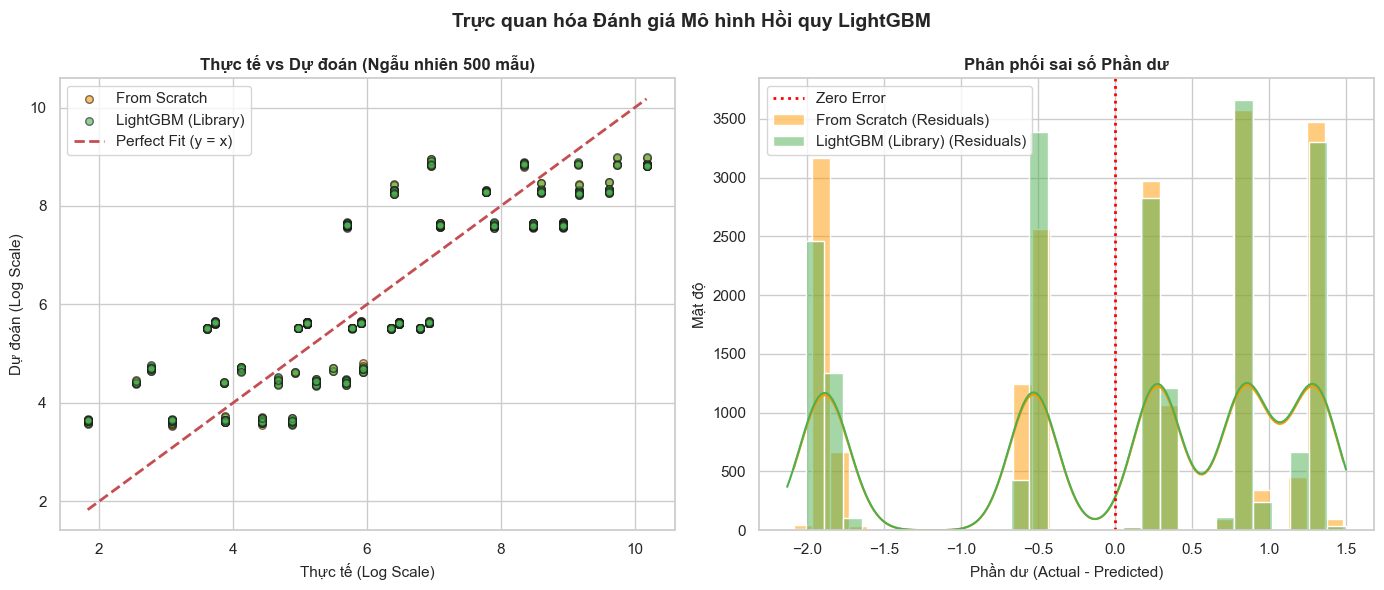

In [5]:
# Khởi tạo hình vẽ có 2 biểu đồ trực quan (Actual vs Predicted Scatter & Residuals Distribution)
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# 1. Biểu đồ Actual vs Predicted (so sánh hai mô hình trên log-scale)
# Chọn ngẫu nhiên 500 mẫu để hiển thị trực quan rõ ràng hơn, không bị dày đặc
np.random.seed(42)
indices = np.random.choice(len(y_test), size=500, replace=False)

axes[0].scatter(y_test[indices], y_pred_log_scratch[indices], color='#FF9800', alpha=0.6, label='From Scratch', edgecolors='k', s=30)
axes[0].scatter(y_test[indices], y_pred_log_sklearn[indices], color='#4CAF50', alpha=0.6, label='LightGBM (Library)', edgecolors='k', s=30)
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='Perfect Fit (y = x)')

axes[0].set_xlabel('Thực tế (Log Scale)', fontsize=11)
axes[0].set_ylabel('Dự đoán (Log Scale)', fontsize=11)
axes[0].set_title('Thực tế vs Dự đoán (Ngẫu nhiên 500 mẫu)', fontsize=12, fontweight='bold')
axes[0].legend()

# 2. Biểu đồ Phân phối Phần dư (Residuals Distribution)
residuals_scratch = y_test - y_pred_log_scratch
residuals_sklearn = y_test - y_pred_log_sklearn

sns.histplot(residuals_scratch, color='#FF9800', alpha=0.5, kde=True, ax=axes[1], label='From Scratch (Residuals)', bins=30)
sns.histplot(residuals_sklearn, color='#4CAF50', alpha=0.5, kde=True, ax=axes[1], label='LightGBM (Library) (Residuals)', bins=30)

axes[1].axvline(x=0, color='red', linestyle=':', lw=2, label='Zero Error')
axes[1].set_xlabel('Phần dư (Actual - Predicted)', fontsize=11)
axes[1].set_ylabel('Mật độ', fontsize=11)
axes[1].set_title('Phân phối sai số Phần dư', fontsize=12, fontweight='bold')
axes[1].legend()

plt.suptitle('Trực quan hóa Đánh giá Mô hình Hồi quy LightGBM', fontsize=14, fontweight='bold')
plt.tight_layout()

# Lưu trữ mô hình scratch tốt nhất vào thư mục models
MODEL_DIR = './models'
os.makedirs(MODEL_DIR, exist_ok=True)
joblib.dump(lgb_scratch, os.path.join(MODEL_DIR, 'model_lightgbm_scratch.pkl'))
print(f"Mô hình LightGBM tự viết đã được lưu tại {os.path.join(MODEL_DIR, 'model_lightgbm_scratch.pkl')}")

plt.show()